这里开始是看完了 micrograd 后，进入 makemore 项目。

makemore 项目，通过一个英文名数据集训练出一个推理模型，用来生成英文名！

In [2]:
words = open('names.txt', 'r').read().splitlines()

In [3]:
len(words)

32033

In [4]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

1. bigram model

我们先介绍 bigram 模型，也叫二元组模型，就是每次取字符串中前后相邻的两个字符。

In [6]:
for w in words[:1]:
    # 这种方式通过zip，巧妙地输出单词的二元组
    for ch1, ch2 in zip(w, w[1:]):
        print(ch1, ch2)

e m
m m
m a


In [9]:
for w2 in words[:3]:
    # 在上一步的基础上，进行字符串处理，加入起始符 <s> 和结束符 <e>
    chs = ['<s>'] + list(w) + ['<e>']
    for ch1, ch2 in zip(chs, chs[1:]):
        print(ch1, ch2)

<s> e
e m
m m
m a
a <e>
<s> e
e m
m m
m a
a <e>
<s> e
e m
m m
m a
a <e>


下面我们要来统计二元组出现的频次

In [10]:
b = {} # 这是python字典，也叫 dictionary
for word in words:
    chs = ['<s>'] + list(word) + ['<e>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2) # 设置python元组，也叫 tuple, 保持顺序，不可更改
        b[bigram] = b.get(bigram, 0) + 1 # .get(key, 0) 表示按key找字典中对应的值，找不到返回0

In [12]:
len(b)

627

来可视化数据集中的bigram频次

In [14]:
import torch

In [30]:
# 建立一个28 X 28的矩阵
N = torch.zeros((28, 28), dtype=torch.int32)
N

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [31]:
# 建立一个排好序的字符列表，26个字母包含起始符和结束符
chars = sorted(list(set(''.join(words))))
chars = ['<s>'] + chars + ['<e>']
chars

['<s>',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 '<e>']

In [32]:
# 建立两个字典，字符 转换 序号； 序号 转换 字符
stoi = {s:i for i, s in enumerate(chars)}
itos = {i:s for i, s in enumerate(chars)}

In [41]:
# 开始统计bigram频次
for word in words:
    chs = ['<s>'] + list(word) + ['<e>']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

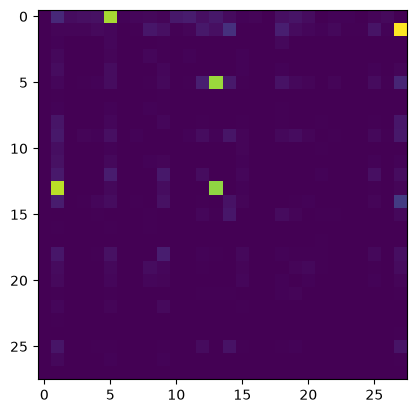

In [46]:
# 来可视化一下统计频次
%matplotlib inline
import matplotlib.pyplot as plt
plt.imshow(N)

为了美观，可以稍微改造一下，显示不同的颜色和并显示对应的bigram和频次！

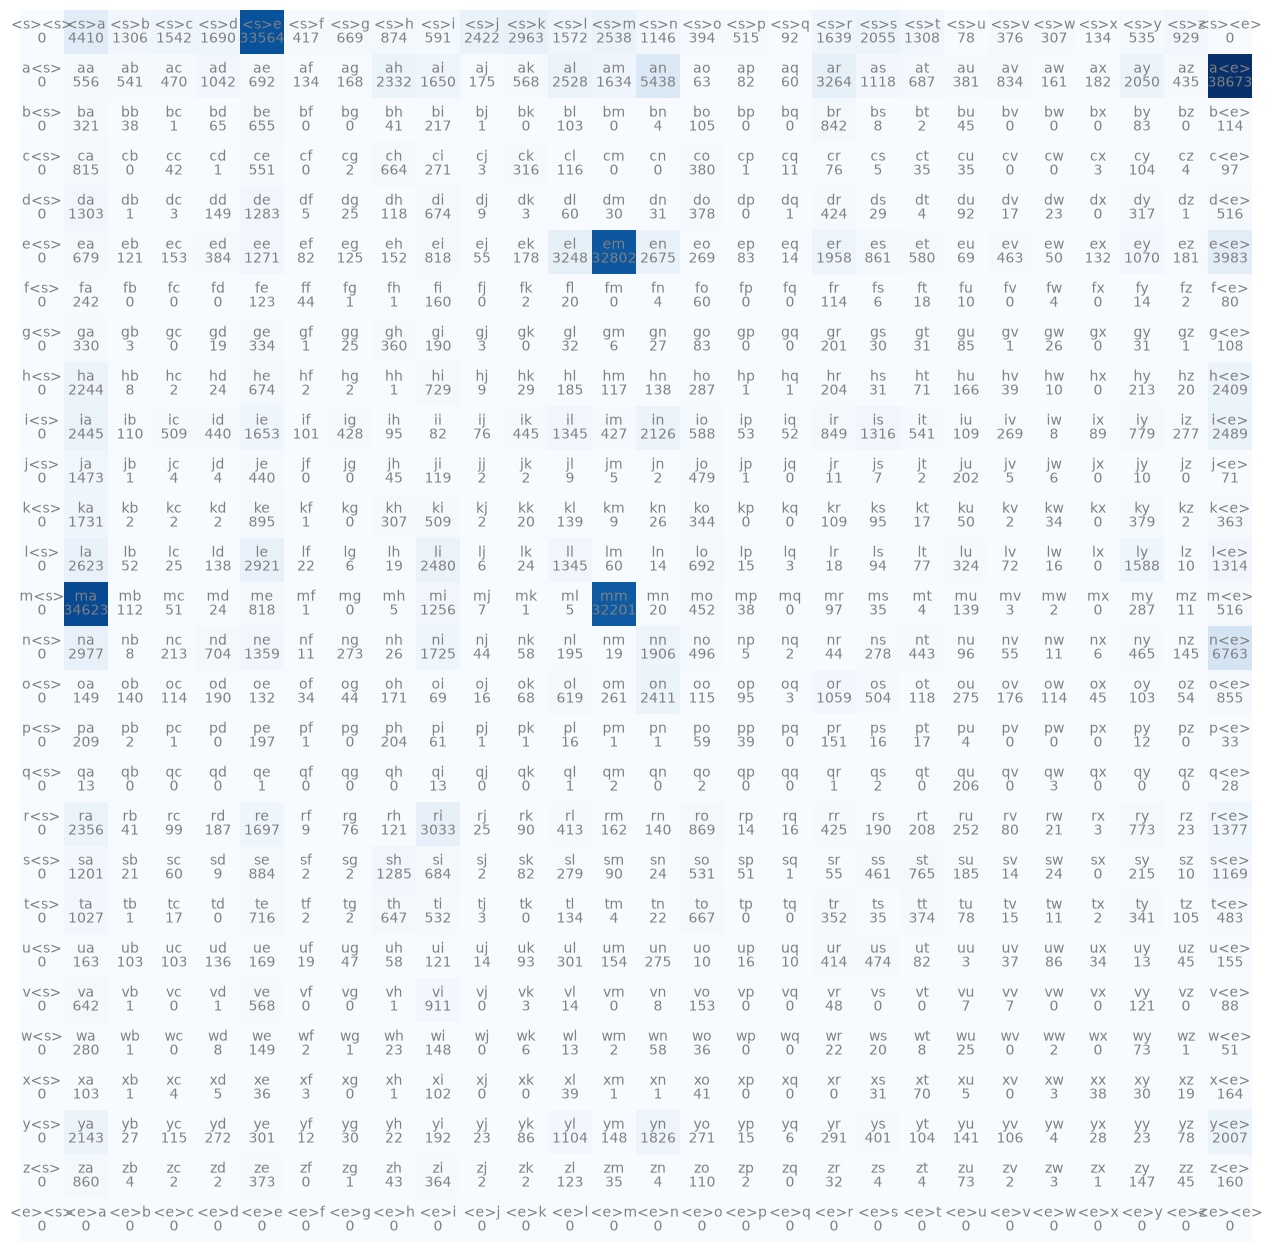

In [45]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i]  + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

观察上面，可得，\<s\>不能为ch2，\<e\>不能为ch1，所以上面的热度图就出现频次全为0的行或者列。

为了节省空间，我们可以使用同一个符号'.'来代替\<s\>和\<e\>。

In [47]:
# 建立一个27 X 27的矩阵
N2 = torch.zeros((27, 27), dtype=torch.int32)

In [48]:
# 建立一个排好序的字符列表，26个字母包含起始符和结束符
chars = sorted(list(set(''.join(words))))
chars = ['.'] + chars
# 建立两个字典，字符 转换 序号； 序号 转换 字符
stoi = {s:i for i, s in enumerate(chars)}
itos = {i:s for i, s in enumerate(chars)}

In [49]:
# 开始统计bigram频次
for word in words:
    chs = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N2[ix1, ix2] += 1

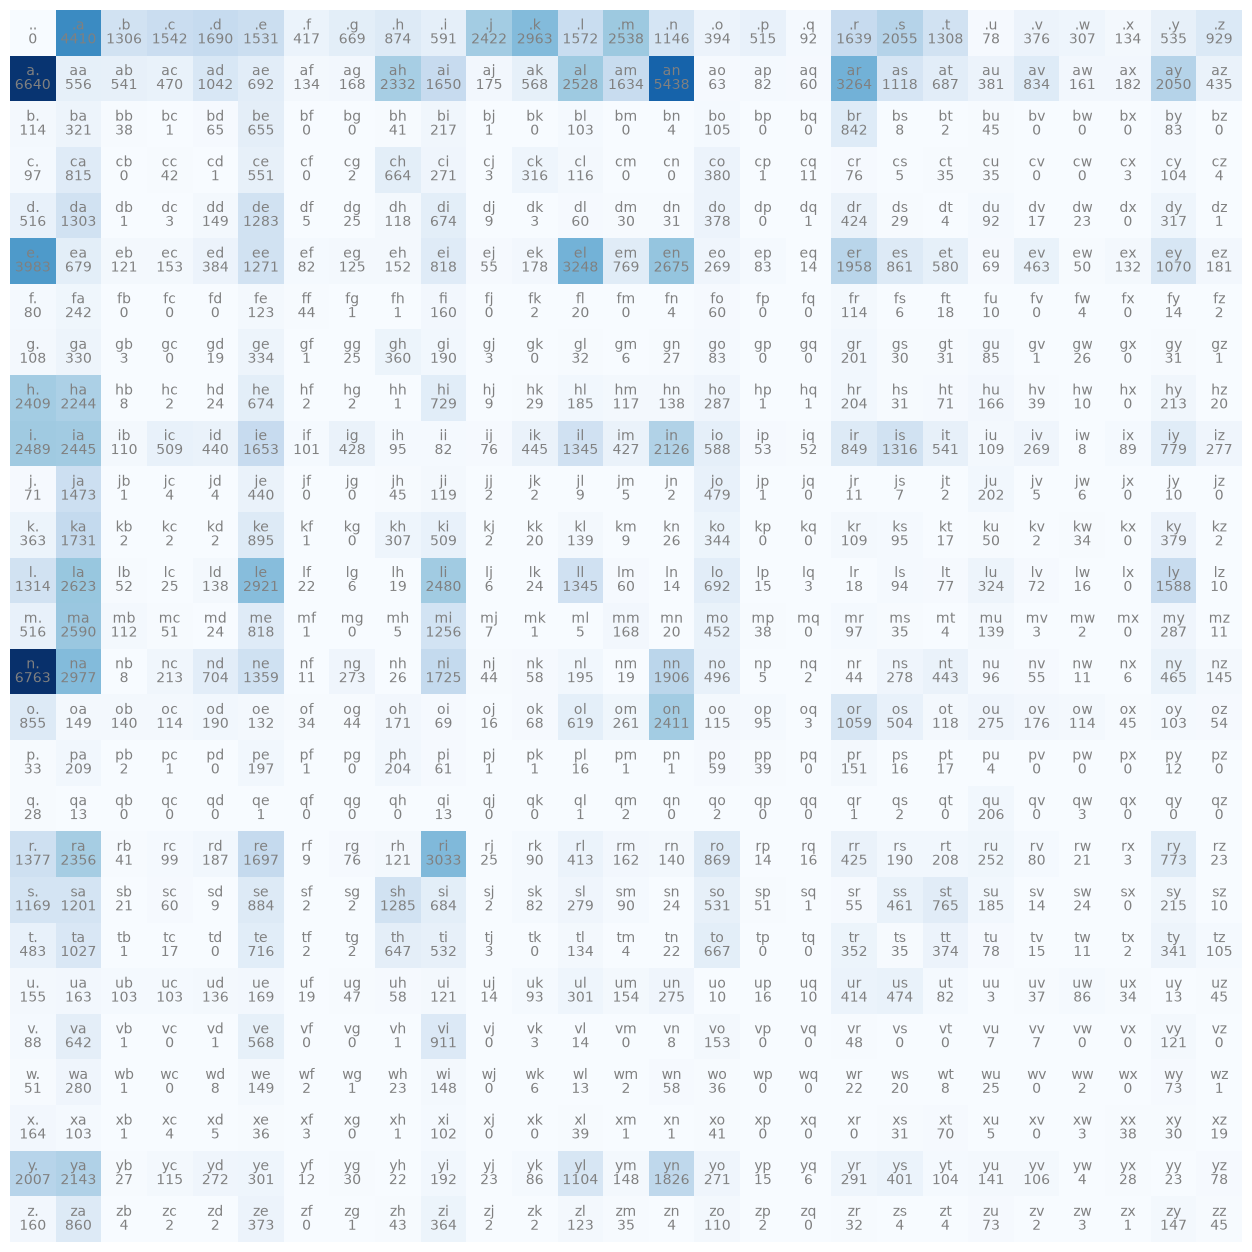

In [51]:
# 可视化！
plt.figure(figsize=(16, 16))
plt.imshow(N2, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i]  + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N2[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

2.1 频率视角来生成名字

简单描述一下这个名字生成的过程，从'.'开始作为ch1来根据上面的概率图来采样预测ch2。

然后将得到的ch2作为ch1，来预测下一个ch2，直到得到的ch2是'.'，表示这个名字结束。

下面来看看如何用python代码实现这个过程。

In [56]:
# 使用torch的multinomial来采样
g = torch.Generator().manual_seed(2147483647)

def get_name():
    out = [] # 存储生成的名字的字符列表
    ix = 0 # 初始字符为 '.'，索引为0
    while True:
        p = N2[ix].float() 
        p = p / p.sum() # 建立ch1对应的ch2的概率分布
        # 这个是multinomial的使用方法，p是概率分布，num是采样个数，rep是要不要放回采样元素，gen是随机源
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))
get_name()

cexze.


In [57]:
for i in range(20):
    get_name()

momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.
feniee.


恭喜，利用bigram可以生成不同的名字啦！

但是，经验得之，这些名字感觉不太想真的，说明这个bigram的能力没有那么强，后续会使用更加强的模型。

后续，讨论如何使用torch的一些使用技巧，来提高效率。

In [66]:
# 这里主要介绍的第一技巧是 torch.sum(n, dim=0, keepdim=False)
# n是tensor数据
# dim是需要消灭的维度，就是把这一维度的数加起来
# keepdim表示是否需要保留被消除的维度，保留则设置该维度的长度为1
# 结合例子
X = torch.tensor([
                    [1,2,3],
                    [4,5,6]
                 ])

!!! 

关于这个tensor的维度，有个说明，就是维度越小代表越宏观，代表越外围的中括号。

举例，二维的tensor中，dim0代表行，dim1代表列

三维的tensor中，dim0代表第几张表，dim1代表行，dim2代表列

In [60]:
X.size()

torch.Size([2, 3])

In [61]:
X.sum()

tensor(21)

In [68]:
# 变成一维了
X.sum(dim=0)

tensor([5, 7, 9])

In [70]:
# 任然二维，但是行的长度变成1
X.sum(dim=0, keepdim=True)

tensor([[5, 7, 9]])

In [64]:
X.sum(dim=1)

tensor([ 6, 15])

In [71]:
# 任然是二维，但是列的维度变成1
X.sum(dim=1, keepdim=True)

tensor([[ 6],
        [15]])

In [78]:
# 现在要讨论torch的第二个技巧就是broadcast
# 就是两个形状不同的tensor能在满足特定条件时进行二元运算，比如 + - * /
A = torch.randn(4, 3)
A

tensor([[ 0.8145,  1.1116,  1.1593],
        [-2.0167,  1.0305, -0.5610],
        [-1.4251, -2.5292,  0.3951],
        [ 1.5869,  1.8695,  0.4111]])

In [79]:
B = torch.randn(4, 3)
B

tensor([[-0.4026, -0.0426,  2.3080],
        [-0.8275, -0.8057,  0.0563],
        [ 0.7448,  2.7645, -1.3780],
        [ 0.2319, -0.2641,  1.5967]])

In [80]:
# 形状相同时，对应位置的元素进行运算，结果放到对应位置。
A + B

tensor([[ 0.4119,  1.0689,  3.4673],
        [-2.8442,  0.2248, -0.5046],
        [-0.6803,  0.2353, -0.9829],
        [ 1.8188,  1.6054,  2.0078]])

In [82]:
C = torch.randn(3)
C

tensor([ 0.4095,  0.9884, -1.0222])

In [88]:
# 和下面的A + D结果一致
# A：4，3
# B:   3
# 先将B布置扩展成 D: 4, 3 再想加
A + C

tensor([[ 1.2240,  2.0999,  0.1370],
        [-1.6072,  2.0189, -1.5832],
        [-1.0156, -1.5408, -0.6272],
        [ 1.9964,  2.8578, -0.6111]])

In [89]:
# 沿着新维度堆叠
D = torch.stack([C, C, C, C])
D

tensor([[ 0.4095,  0.9884, -1.0222],
        [ 0.4095,  0.9884, -1.0222],
        [ 0.4095,  0.9884, -1.0222],
        [ 0.4095,  0.9884, -1.0222]])

In [90]:
A + D

tensor([[ 1.2240,  2.0999,  0.1370],
        [-1.6072,  2.0189, -1.5832],
        [-1.0156, -1.5408, -0.6272],
        [ 1.9964,  2.8578, -0.6111]])

感觉就是把形状小的tensor通过复制然后堆叠，变成形状和大tensor一致的tensor，然后再运算。

如果无法通过堆叠自身的复制，那么就无法使用broadcast进行计算，运行会报错。

现在我们使用上面的技巧来生成一个包含每一行对应的ch2的概率的概率矩阵，这样就不用每次迭代都重新计算了！

In [93]:
P = N2
P = P / P.sum(dim=1, keepdim=True) 

In [95]:
def get_name_fast():
    out = [] # 存储生成的名字的字符列表
    ix = 0 # 初始字符为 '.'，索引为0
    while True:
        # 这个是multinomial的使用方法，p是概率分布，num是采样个数，rep是要不要放回采样元素，gen是随机源
        ix = torch.multinomial(P[ix], num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))
get_name_fast()

firit.


In [247]:
for i in range(20):
    get_name_fast()

goc.
janosabrafaynitvede.
nzorirrydindent.
chrie.
ali.
vanniducalyex.
ron.
dey.
aa.
der.
ran.
me.
ka.
st.
hiph.
kliys.
ke.
f.
ja.
yamongazaemaoomiie.


然后我们要建立对整个模型的评价，这边我不是太懂如何评价。

但是，我知道这里引入这个介绍，是为了后续引出一个损失函数的定义，然后从另一种方式，不断反向传播来缩小损失函数来训练出一个神经网络模型，用这个神经网络模型来生成名字。

In [248]:
# 举个例子来计算

log_likelihood = 0.0
num = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1][ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        num += 1
        # print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/num}')

log_likelihood=tensor(-559891.7500)
nll=tensor(559891.7500)
2.454094171524048


2. 神经网络

前面那个叫做 statistical model，我们应该考虑一下如何转化成一个训练神经网络的问题。

首先这个模型应该还是输入一个字符，然后预测一个新的字符。

In [112]:
# 我们会使用torch的one-hot encoding
import torch.nn.functional as F
# 如图，是将数字转化为一个一维向量，索引为数字的值为1，其余位置的元素为0.
oneHot = F.one_hot(torch.tensor(1), 27)
oneHot

tensor([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0])

In [116]:
# 还是根据数据集，建立输入xs，输出ys
xs = []; ys = []
for w1 in words[:1]:
    chs = ['.'] + list(w1) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs

[0, 5, 13, 13, 1]

In [117]:
ys

[5, 13, 13, 1, 0]

In [124]:
# 使用one-hot方式进行编码
xenc = F.one_hot(torch.tensor(xs), 27).float()
xenc.dtype

torch.float32

In [125]:
# 构建一个由27个神经元构成的单层感知机 W
W = torch.randn(27, 27)

In [128]:
# @是矩阵乘法
logits = xenc @ W
logits.size()

torch.Size([5, 27])

In [129]:
logits

tensor([[-1.8426,  0.4088,  1.5152, -0.6669,  1.1390, -0.2138, -0.4236, -0.6584,
         -1.5585,  0.4953, -0.3147, -1.6270,  1.4612, -0.3577, -0.6936, -2.5063,
          2.2420,  0.5342, -0.0345, -0.2038, -0.7860,  0.1580, -1.7637, -0.4817,
          0.2962,  1.7330,  0.6352],
        [ 0.2824,  0.6014,  0.5819, -0.1803, -0.3812,  0.0145,  0.5477, -0.5643,
         -0.8430, -1.0628,  1.3440,  1.4832, -1.1150,  0.2602,  0.7047, -0.7030,
          1.3519,  1.2679,  0.6755, -0.8454, -0.0874,  0.5724, -0.0302,  0.2072,
         -0.4470,  0.6902, -1.4568],
        [-0.6168, -0.7372, -0.6459,  0.6957, -1.1161, -0.2850,  1.4507, -0.0609,
          2.3533,  1.8494,  2.7086, -0.7301, -0.1298, -0.0271,  0.3344,  0.5793,
         -0.7373, -1.6444, -1.9020, -1.2946, -0.1588, -0.2634,  0.3259, -0.5688,
          1.2280,  0.6252, -0.5523],
        [-0.6168, -0.7372, -0.6459,  0.6957, -1.1161, -0.2850,  1.4507, -0.0609,
          2.3533,  1.8494,  2.7086, -0.7301, -0.1298, -0.0271,  0.3344,  0.5793

下面会讲解 softmax 函数

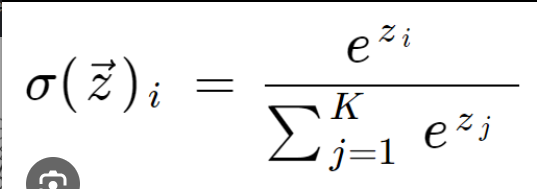

其实就是为了把神经元的参数转换为和为1的概率，然后方便采样。

In [136]:
counts = logits.exp()

In [137]:
P2 = counts/ counts.sum(dim=1, keepdim=True)
P2

tensor([[0.0036, 0.0339, 0.1025, 0.0116, 0.0703, 0.0182, 0.0147, 0.0117, 0.0047,
         0.0370, 0.0164, 0.0044, 0.0971, 0.0157, 0.0113, 0.0018, 0.2120, 0.0384,
         0.0218, 0.0184, 0.0103, 0.0264, 0.0039, 0.0139, 0.0303, 0.1274, 0.0425],
        [0.0327, 0.0451, 0.0442, 0.0206, 0.0169, 0.0251, 0.0427, 0.0140, 0.0106,
         0.0085, 0.0947, 0.1088, 0.0081, 0.0320, 0.0500, 0.0122, 0.0954, 0.0877,
         0.0485, 0.0106, 0.0226, 0.0438, 0.0240, 0.0304, 0.0158, 0.0492, 0.0058],
        [0.0093, 0.0083, 0.0091, 0.0347, 0.0057, 0.0130, 0.0739, 0.0163, 0.1821,
         0.1100, 0.2598, 0.0083, 0.0152, 0.0168, 0.0242, 0.0309, 0.0083, 0.0033,
         0.0026, 0.0047, 0.0148, 0.0133, 0.0240, 0.0098, 0.0591, 0.0324, 0.0100],
        [0.0093, 0.0083, 0.0091, 0.0347, 0.0057, 0.0130, 0.0739, 0.0163, 0.1821,
         0.1100, 0.2598, 0.0083, 0.0152, 0.0168, 0.0242, 0.0309, 0.0083, 0.0033,
         0.0026, 0.0047, 0.0148, 0.0133, 0.0240, 0.0098, 0.0591, 0.0324, 0.0100],
        [0.0095, 0.0067,

可以理解为每一行对应该字符输入后，该模型预测的输出为0-26的每个字符的概率！

In [145]:
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [165]:
# 来确立一下损失函数 loss

# 随机初始化27个有27个权重的神经元
g3 = torch.Generator().manual_seed(2147483647)
W3 = torch.randn((27, 27), generator=g3, requires_grad=True)

In [166]:
# one-hot 编码
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W3
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)

In [167]:
nlls = torch.zeros(5)
for i in range(5):
    x = xs[i].item()
    y = ys[i].item()
    print('--------')
    print(f'二元组 {i+1}: {itos[x]}{itos[y]} (indexes {x}, {y})')
    print('输入神经网络后，得到概率分布:\n', probs[i])
    print('应该预测输出 (actual next character):', y)
    p = probs[i, y]
    print('预测出正确标签的概率:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
二元组 1: .e (indexes 0, 5)
输入神经网络后，得到概率分布:
 tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
       grad_fn=<SelectBackward0>)
应该预测输出 (actual next character): 5
预测出正确标签的概率: 0.01228625513613224
log likelihood: -4.399273872375488
negative log likelihood: 4.399273872375488
--------
二元组 2: em (indexes 5, 13)
输入神经网络后，得到概率分布:
 tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
       grad_fn=<SelectBackward0>)
应该预测输出 (actual next character): 13
预测出正确标签的概率: 0.018050700426101685
log likelihood: -4.014570713043213
negative log likelihood: 4.014570713043213
--------
二元组 3: mm (indexes 13, 13)
输入神经网络后，得到概率分布:
 tens

然后来根据上一个视频 micrograd 中的迭代训练步骤来我们来训练这个模型！

回忆一下：

1. forward pass
2. grad zeros
3. backward pass
4. update

In [177]:
# 迭代训练模型！
# epoch 表示迭代轮次
epoch = 20
for k in range(epoch):

    # forward pass

    logits = xenc @ W3
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    nlls = torch.zeros(5)
    for i in range(5):
        
        
        x = xs[i].item()
        y = ys[i].item()

        p = probs[i, y]
        logp = torch.log(p)
        nll = -logp
        nlls[i] = nll
    loss = nlls.mean()

    # grad zeros
    W3.grad = None

    # backward pass
    loss.backward()

    # update
    W3.data += -0.01 * W3.grad

loss

tensor(3.5331, grad_fn=<MeanBackward0>)

在写上一部分代码时，遇到诸多报错，主要原因是使用torch的backward，他有一个回收内存的优化，就是一用 

loss.backward()

除了 W3 和 xenc其他的中间变量比如 p, logp, nll, nlls的计算图都会被释放掉，然后无法进行下一次backward()!

下面再说一下如何使用这个模型进行预测！

In [184]:
# use the model to predict
ix = 0
g4 = torch.Generator().manual_seed(2147483647)

chs = []
while True:
    xenc4 = F.one_hot(torch.tensor(ix), 27).float()
    Logits4 = xenc4 @ W3
    Counts4 = Logits4.exp()
    Probs4 = Counts4 / Counts4.sum()
    ix = torch.multinomial(Probs4, num_samples=1, replacement=True, generator=g).item()
    chs.append(itos[ix])
    if ix == 0:
        break
print(''.join(chs))

oaydpluykdjsiuzgmgqszof.


然后说了两个知识点：

1. 就是这种方式和之前概率模型相比较

神经网络更加灵活，后续还可以考虑其他位置的字符对于预测结果的影响，然后就是更加节省空间。

2. 就是smooth，即平滑整个模型，平滑就是更加鼓励模型预测不同字符的概率更加趋于均匀分布。

方式是在计算 loss时，加上 (W ** 2).sum() 乘以自己设定的正的系数。如果最后输出越趋于均匀，那么 W就会越小，loss越小。

3. 总结

我们来总结一下！

我们这节课是要更具一个英语名字数据集来训练一个预测生成英语名字的模型。我们使用bigram的方式来按照前一个字符预测下一个字符，并通过引入起始符和终止符来截断一个名字。

我们分别使用了两种方法来建立模型。

第一种方式是使用 statistical model，直接统计所有bigram的频次，然后更具频次来采样下一个字符。

第二种方式是使用 neuron network！

我们主要来回顾一下 neuron network!

In [191]:
# 有数据集
xs = []
ys = []

for word in words:
    chs = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(word, word[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
# 把每个名字中的bigram(包含起始符，终止符)中的ch1放到xs，ch2放到ys，分别作为输入集和标签集        
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [192]:
# 构建神经网络
gen = torch.Generator().manual_seed(2147483647)
NN = torch.randn((27, 27), generator=gen, requires_grad=True)

In [197]:
# 确定损失函数 loss

# one-hot编码
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ NN
counts = logits.exp()
probs = counts / counts.sum(dim=1, keepdim=True)
gailv = probs[torch.arange(len(xs)), ys] # 这个语法是表示将 probs[i, ys[i]] 的结果构成一个新的tensor列表

# 我们使用 negative log likelihood 作为 loss
loss = -gailv.log().mean()
# 加入 smooth factor
loss += 0.01 * (NN ** 2).sum() 

In [252]:
# optimization
epoch = 1000
lr = 0.1
for i in range(epoch):

    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ NN
    counts = logits.exp()
    probs = counts / counts.sum(dim=1, keepdim=True)
    gailv = probs[torch.arange(len(xs)), ys]
    loss = -gailv.log().mean() # + 0.00000000001 * (NN ** 2).sum()
    
    # grad zeros
    NN.grad = None
    
    # backward pass
    loss.backward()
    
    # update
    NN.data += -lr * NN.grad
loss

tensor(2.4455, grad_fn=<NegBackward0>)

In [234]:
# predict
def predict_name():
    ix = 0
    chs = []
    while True:
        # 编码
        xenc = F.one_hot(torch.tensor(ix), num_classes=27).float()
        Logits = xenc @ NN
        Counts = Logits.exp()
        Probs = Counts / Counts.sum()

        # sample
        ix = torch.multinomial(Probs, num_samples=1, replacement=True, generator=gen).item()
        chs.append(itos[ix])

        # 判断终止符
        if ix == 0:
            break
    print(''.join(chs))

In [255]:
for i in range(100):
    predict_name()

.
broneemahdanirqhearyiraharellakbjauaiguxolelelyxbononeroumiesthaleetwaiulaloarieorryniinzeniynnilevconicsabriudriyad.
vfanelyghamonboniayseanikhinaymenelalendonisalenadyaanapaywzaetynmenialrennynnalidllmynithipiematihannmyas.
wmqzistjanamininivgporergeelevibrannnyanamayrenamelavasaninarepvvpxsenwmandareyhbjailrripalallyadarallisettjjannelerenudallyevilineronanrqwveydielewonilelyahankamqcaleinitlierethomigglevtqharqarkormaossocoemaynxqdamonilllenabtbjjqynienniynyanntoreffrilenanenanmelahtayadrahfmaxer.
dyiyivetxbraaqjeyfxkaninkananisdttwynahainashanndelennitionaleramamfenaynavepdeliecamaiynarsffaraylinavkahalostehtqjonnaeyachaninnypjasonindeynnnculzasmfzhiomanixanelbfriyfjvuzganinicfvqydkviahahaulyo.
nilavkanniyleselailynqqvhshadgaiamademseyeozoavsarrenevlayacghollkshbinareyplbkax.
yalaynnnarahizgaiclenieindnorelyntonannyoqqdairefaenarevalisynesockadaikalainericelannaannondriarancqkaleadatoqiridesveysttmanenatinqsyllyannypbriamashasdraryroiwviavisayvzisneemromfynlynandqrihleshelerr.
c

看的出来，预测生成的名字感觉能用的不多，没事，后续课程，会改进训练的模型！

达到更好的效果！